## 03. Preprocesamiento y reducción de dimensionalidad: Heart Disease
Codificación, escalado, PCA y visualización, con decisiones justificadas por el EDA.

In [1]:
from pathlib import Path
from hashlib import sha256
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
import sklearn
print("scikit-learn:", sklearn.__version__)

scikit-learn: 1.9.1


## 3.1 Cargar la misma base y comprobar su estructura
No se modifica el CSV original. Se conserva su hash para comprobar que las fases usen los mismos datos.

In [2]:
cwd = Path.cwd()
candidatas = [cwd, *cwd.parents]
raiz = next((p for p in candidatas if (p / "data" / "Heart_Disease_UCI.csv").exists()), None)
if raiz is None:
    raiz = cwd.parent if cwd.name == "03_preprocesamiento" else cwd
RUTA_CSV = raiz / "data" / "Heart_Disease_UCI.csv"
URL = "https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv"
if not RUTA_CSV.exists():
    RUTA_CSV.parent.mkdir(parents=True, exist_ok=True)
    pd.read_csv(URL).to_csv(RUTA_CSV, index=False)
df = pd.read_csv(RUTA_CSV, na_values=["?", "", "NA"])
SALIDA = raiz / "03_preprocesamiento" / "resultados_heart"
SALIDA.mkdir(parents=True, exist_ok=True)
continuas = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categoricas = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
assert set(df.columns) == set(continuas + categoricas + ["target"]), "Revisar esquema"
assert df["target"].notna().all() and set(df["target"].unique()) == {0, 1}
print("Fuente:", RUTA_CSV)
print("SHA-256:", sha256(RUTA_CSV.read_bytes()).hexdigest())
print("Dimensiones:", df.shape)
display(df.head())

Fuente: d:\2. Estudios\4. Ingenieria Sistemas\Semestre 10\Análisis de datos\Entregable 2\analisis-datos-evento2-grupo7\data\Heart_Disease_UCI.csv
SHA-256: 4006bdf58b69dd3faaf7755e78f1ceb37ce1e6ddb6e9c4973620adfb80ec4695
Dimensiones: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## 3.2 Decisiones de limpieza y selección
| Hallazgo del EDA | Decisión en esta fase | Justificación |
|---|---|---|
| Una fila adicional idéntica | Eliminar repetidos completos antes de dividir | Evita que copias idénticas aparezcan en entrenamiento y prueba; no hay identificador para confirmar si representan pacientes distintos |
| Sin nulos explícitos | Comprobar de nuevo e incluir imputación como respaldo | La mediana y la moda se calculan solamente con entrenamiento |
| `ca=4` y `thal=0` pendientes de documentación | Conservar como categorías propias | No declarar errores ni imputar códigos sin evidencia |
| Valores extremos en medidas continuas | Conservar y registrar | Un extremo estadístico no implica un error; no recortar medidas clínicas automáticamente |
| `chol` y `oldpeak` asimétricas | Estandarizar sin transformación logarítmica inicial | PCA no exige normalidad; se conserva la escala interpretativa original antes del escalado |
| Códigos categóricos almacenados como enteros | One-Hot para las ocho columnas categóricas | Evita imponer distancias u orden; `ca` se trata provisionalmente por categorías por la duda sobre sus códigos |
| `target` es el objetivo | Mantener fuera de imputación, escalado y PCA | Evita incorporar la respuesta en las variables predictoras |

Se conserva la primera aparición de cada fila completa. Esta es una decisión explícita del análisis, revisable si se recuperan identificadores de pacientes.

In [5]:
calidad = pd.Series({
    "Filas originales": len(df),
    "Duplicados adicionales": int(df.duplicated().sum()),
    "Celdas nulas": int(df.isna().sum().sum()),
    "Filas con ca=4": int(df["ca"].eq(4).sum()),
    "Filas con thal=0": int(df["thal"].eq(0).sum()),
}, name="Cantidad")
display(calidad.to_frame())
datos = df.drop_duplicates().copy()
datos.index.name = "fila_origen"
X = datos[continuas + categoricas].copy()
y = datos["target"].astype(int).copy()
# No modificar el original ni mezclar el objetivo con los predictores.
assert "target" not in X.columns
assert np.isfinite(X.to_numpy(dtype=float)[~X.isna().to_numpy()]).all()
print("Filas tras retirar repetidos:", len(datos))
resumen_extremos = []
for col in continuas:
    q1, q3 = X[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    resumen_extremos.append({"variable": col, "posibles_atipicos_IQR": int(((X[col] < q1-1.5*iqr) | (X[col] > q3+1.5*iqr)).sum())})
display(pd.DataFrame(resumen_extremos))

,Cantidad
Filas originales,303
Duplicados adicionales,1
Celdas nulas,0
Filas con ca=4,5
Filas con thal=0,2


Filas tras retirar repetidos: 302


,variable,posibles_atipicos_IQR
0,age,0
1,trestbps,9
2,chol,5
3,thalach,1
4,oldpeak,5


## 3.3 Separar entrenamiento y prueba
Se reserva el 20 % como prueba con división estratificada y semilla fija. La imputación, codificación, escalado y PCA se ajustan con entrenamiento; la prueba se transforma con esos parámetros. Los resultados de PCA corresponden a esa partición, no a un ajuste sobre los 302 registros completos.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)
assert set(X_train.index).isdisjoint(X_test.index)
resumen_particion = pd.DataFrame({
    "entrenamiento": y_train.value_counts().sort_index(),
    "prueba": y_test.value_counts().sort_index()
}).fillna(0).astype(int)
display(resumen_particion)
print("Entrenamiento:", X_train.shape, "Prueba:", X_test.shape)

,entrenamiento,prueba
target,,
0,110,28
1,131,33


Entrenamiento: (241, 13) Prueba: (61, 13)


## 3.4 Codificación y escalado
Las cinco medidas continuas se imputan con mediana si hace falta y se estandarizan a media cercana a 0 y desviación poblacional cercana a 1 en entrenamiento. Las ocho categorías se imputan con moda si hace falta y se codifican con One-Hot completo, sin descartar una categoría de referencia.

Las columnas One-Hot permanecen en 0/1. Así no se amplifican automáticamente las categorías raras al estandarizarlas. Es una elección de ponderación: PCA sobre datos mixtos depende de esta decisión y las variables con varias categorías pueden tener mayor contribución conjunta. No se interpreta como una distancia clínica validada. `handle_unknown="ignore"` permite transformar categorías nuevas como ceros; su aparición debe revisarse antes de usar un futuro modelo.

In [7]:
# Compatibilidad con versiones que usan sparse en lugar de sparse_output.
try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop=None)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False, drop=None)
preprocesador = ColumnTransformer([
    ("continuas", Pipeline([
        ("imputar", SimpleImputer(strategy="median")),
        ("escalar", StandardScaler())
    ]), continuas),
    ("categoricas", Pipeline([
        ("imputar", SimpleImputer(strategy="most_frequent")),
        ("codificar", encoder)
    ]), categoricas)
], remainder="drop")
Z_train = preprocesador.fit_transform(X_train)
Z_test = preprocesador.transform(X_test)
nombres = preprocesador.get_feature_names_out()
train_preparado = pd.DataFrame(Z_train, columns=nombres, index=X_train.index)
test_preparado = pd.DataFrame(Z_test, columns=nombres, index=X_test.index)
assert np.isfinite(Z_train).all() and np.isfinite(Z_test).all()
display(train_preparado.head())
print("Predictores originales:", X.shape[1], "Columnas después de One-Hot:", len(nombres))
display(train_preparado.iloc[:, :len(continuas)].agg(["mean", lambda s: s.std(ddof=0)]).round(6))
for col in categoricas:
    nuevas = set(X_test[col].dropna()) - set(X_train[col].dropna())
    if nuevas:
        print("Categorías solo en prueba:", col, sorted(nuevas))

,continuas__age,continuas__trestbps,continuas__chol,continuas__thalach,continuas__oldpeak,categoricas__sex_0,categoricas__sex_1,categoricas__cp_0,categoricas__cp_1,categoricas__cp_2,...,categoricas__slope_2,categoricas__ca_0,categoricas__ca_1,categoricas__ca_2,categoricas__ca_3,categoricas__ca_4,categoricas__thal_0,categoricas__thal_1,categoricas__thal_2,categoricas__thal_3
fila_origen,,,,,,,,,,,,,,,,,,,,,
59,0.289062,-0.192086,1.222784,0.405122,-0.889676,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
247,1.267182,1.590543,0.035438,-1.364273,-0.889676,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
289,0.071702,-0.192086,-0.818618,-0.910582,0.771788,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
288,0.289062,-1.194814,1.889363,-0.320784,1.602520,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
64,0.397742,0.476400,-0.693634,0.677336,-0.889676,0.0,1.0,0.0,0.0,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


Predictores originales: 13 Columnas después de One-Hot: 30


,continuas__age,continuas__trestbps,continuas__chol,continuas__thalach,continuas__oldpeak
mean,0.0,-0.0,0.0,-0.0,-0.0
<lambda>,1.0,1.0,1.0,1.0,1.0


## 3.5 PCA y elección de componentes
PCA crea combinaciones lineales de los predictores preparados. Se selecciona el mínimo número de componentes que conserva al menos el **90 % de la varianza de entrenamiento**, no un porcentaje de precisión o de capacidad de diagnóstico. Se usa One-Hot completo; sus dependencias lineales pueden producir componentes de varianza prácticamente nula.

El objetivo no participa en este ajuste. Los primeros dos componentes se usarán para visualizar; no necesariamente conservan por sí solos el 90 %.

In [8]:
pca_completo = PCA(svd_solver="full").fit(Z_train)
varianza = pca_completo.explained_variance_ratio_
acumulada = np.cumsum(varianza)
umbral = 0.90
n_componentes = int(np.searchsorted(acumulada, umbral) + 1)
pca = PCA(n_components=n_componentes, svd_solver="full")
P_train = pca.fit_transform(Z_train)
P_test = pca.transform(Z_test)
pcs = [f"PC{i+1}" for i in range(n_componentes)]
train_pca = pd.DataFrame(P_train, columns=pcs, index=X_train.index)
test_pca = pd.DataFrame(P_test, columns=pcs, index=X_test.index)
tabla_varianza = pd.DataFrame({
    "componente": np.arange(1, len(varianza)+1),
    "varianza_explicada": varianza,
    "varianza_acumulada": acumulada
})
display(tabla_varianza.round(4))
print(f"De {len(nombres)} columnas codificadas a {n_componentes} componentes; varianza conservada: {pca.explained_variance_ratio_.sum():.2%}")
assert pca.explained_variance_ratio_.sum() >= umbral - 1e-10
assert P_train.shape[1] == P_test.shape[1] == n_componentes

,componente,varianza_explicada,varianza_acumulada
0,1,0.2551,0.2551
1,2,0.1424,0.3974
2,3,0.0996,0.4970
3,4,0.0895,0.5865
4,5,0.0625,0.6490
5,6,0.0567,0.7057
6,7,0.0502,0.7559
7,8,0.0388,0.7947
8,9,0.0322,0.8269
9,10,0.0307,0.8576


De 30 columnas codificadas a 12 componentes; varianza conservada: 90.94%


## 3.6 Visualizaciones
La curva justifica el número elegido. La dispersión muestra entrenamiento y prueba por separado; cada punto representa una fila y el color corresponde al `target` original. Colorear después del ajuste no incorpora el objetivo al PCA. El solapamiento o separación visual no mide el rendimiento de un clasificador.

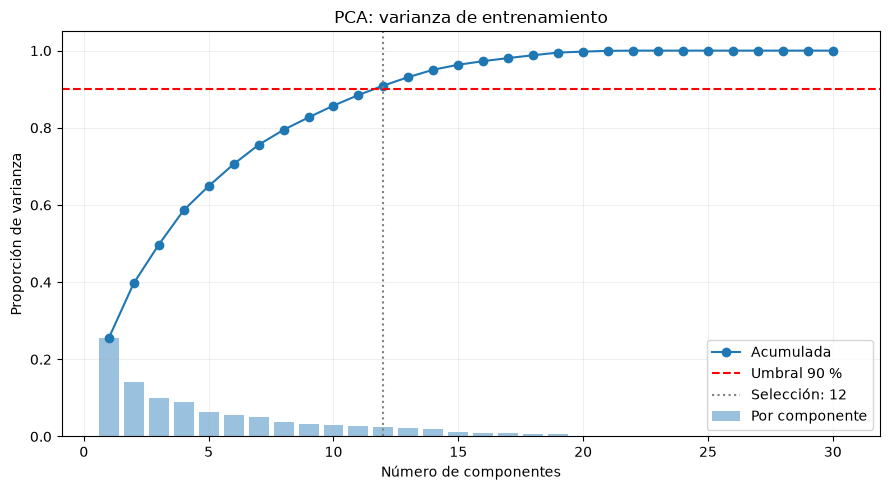

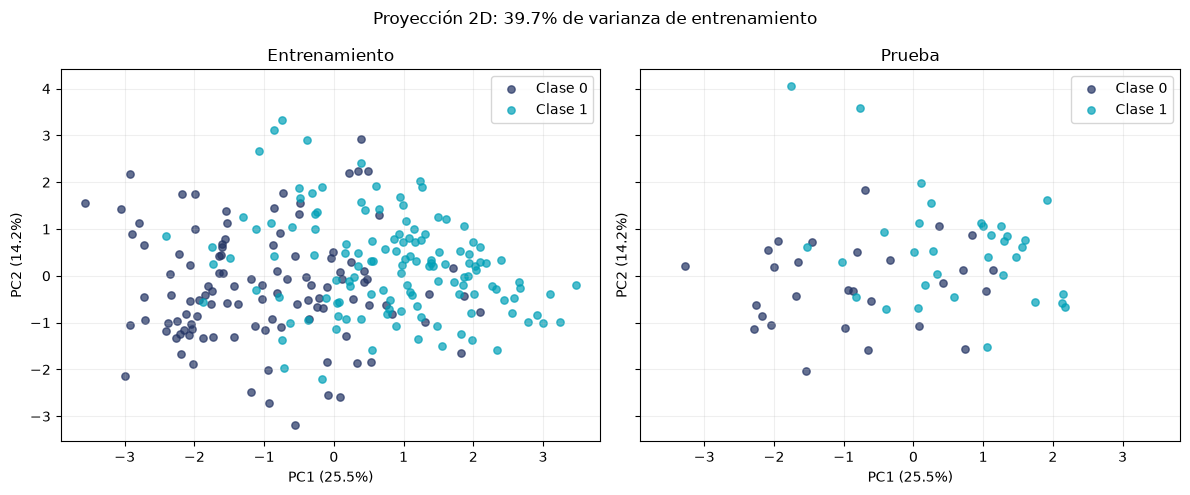

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(tabla_varianza["componente"], varianza, alpha=0.45, label="Por componente")
ax.plot(tabla_varianza["componente"], acumulada, marker="o", label="Acumulada")
ax.axhline(umbral, color="red", linestyle="--", label="Umbral 90 %")
ax.axvline(n_componentes, color="gray", linestyle=":", label=f"Selección: {n_componentes}")
ax.set(xlabel="Número de componentes", ylabel="Proporción de varianza", title="PCA: varianza de entrenamiento", ylim=(0, 1.05))
ax.legend(); ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(SALIDA / "01_varianza_pca.png", dpi=150)
plt.show()

# Ajuste independiente de 2 componentes solo para la visualización.
pca_2d = PCA(n_components=2, svd_solver="full").fit(Z_train)
proyecciones = [pca_2d.transform(Z_train), pca_2d.transform(Z_test)]
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax, puntos, objetivo, titulo in zip(axes, proyecciones, [y_train, y_test], ["Entrenamiento", "Prueba"]):
    for clase, color in [(0, "#233363"), (1, "#00A0B7")]:
        mask = objetivo.to_numpy() == clase
        ax.scatter(puntos[mask, 0], puntos[mask, 1], s=28, alpha=0.7, color=color, label=f"Clase {clase}")
    ax.set(xlabel=f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})", ylabel=f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})", title=titulo)
    ax.legend(); ax.grid(alpha=0.2)
fig.suptitle(f"Proyección 2D: {pca_2d.explained_variance_ratio_.sum():.1%} de varianza de entrenamiento")
fig.tight_layout()
fig.savefig(SALIDA / "02_dispersion_pca.png", dpi=150)
plt.show()

## 3.7 Interpretación de componentes
Los coeficientes muestran qué variables pesan más en cada combinación lineal. Su signo puede invertirse sin cambiar la solución de PCA; no representa una relación causal ni una importancia predictiva. Se muestran los ocho pesos absolutos mayores de los primeros dos componentes.

Mayores pesos: PC1


,PC1
continuas__thalach,0.4981
continuas__oldpeak,-0.4501
continuas__age,-0.4234
continuas__trestbps,-0.2749
categoricas__slope_2,0.2099
continuas__chol,-0.1974
categoricas__slope_1,-0.1749
categoricas__cp_0,-0.1608


Mayores pesos: PC2


,PC2
continuas__chol,0.5848
continuas__trestbps,0.4846
continuas__age,0.3263
continuas__oldpeak,-0.2692
continuas__thalach,0.2572
categoricas__sex_1,-0.1582
categoricas__sex_0,0.1582
categoricas__thal_2,0.1563


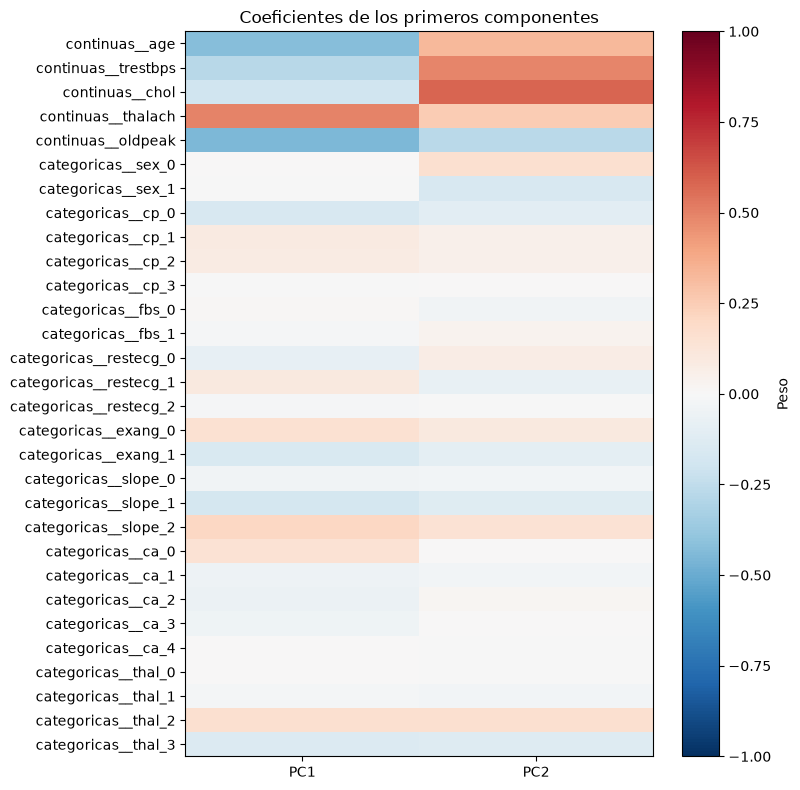

In [10]:
pesos = pd.DataFrame(pca_2d.components_.T, index=nombres, columns=["PC1", "PC2"])
for pc in pesos:
    seleccion = pesos[pc].abs().sort_values(ascending=False).head(8).index
    print("Mayores pesos:", pc)
    display(pesos.loc[seleccion, [pc]].round(4))
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(pesos.to_numpy(), cmap="RdBu_r", aspect="auto", vmin=-1, vmax=1)
ax.set_yticks(range(len(nombres)), nombres)
ax.set_xticks([0, 1], ["PC1", "PC2"])
ax.set_title("Coeficientes de los primeros componentes")
fig.colorbar(im, ax=ax, label="Peso")
fig.tight_layout()
fig.savefig(SALIDA / "03_pesos_componentes.png", dpi=150)
plt.show()

## 3.8 Exportación para un futuro modelado
Se exportan datos codificados/escalados y datos reducidos, con entrenamiento y prueba separados. Cada CSV incluye `fila_origen` para trazabilidad y `target` para uso posterior. **Al entrenar, excluir ambos de los predictores.** El archivo Joblib conserva el preprocesador y el PCA ya ajustados; debe cargarse con versiones compatibles y solo si su origen es confiable.

In [11]:
for nombre, tabla, objetivo in [
    ("train_preprocesado", train_preparado, y_train),
    ("test_preprocesado", test_preparado, y_test),
    ("train_pca", train_pca, y_train),
    ("test_pca", test_pca, y_test),
]:
    exportar = tabla.join(objetivo.rename("target"))
    assert exportar["target"].notna().all()
    exportar.to_csv(SALIDA / f"{nombre}.csv", index=True)
tabla_varianza.to_csv(SALIDA / "varianza_pca.csv", index=False)
pesos.to_csv(SALIDA / "pesos_pca_2d.csv")
joblib.dump({"preprocesador": preprocesador, "pca": pca,
             "continuas": continuas, "categoricas": categoricas}, SALIDA / "transformaciones.joblib")
resumen = {
    "sha256_csv": sha256(RUTA_CSV.read_bytes()).hexdigest(),
    "filas_originales": len(df), "filas_sin_duplicados": len(datos),
    "filas_train": len(X_train), "filas_test": len(X_test),
    "columnas_codificadas": len(nombres), "componentes": n_componentes,
    "varianza_conservada": float(pca.explained_variance_ratio_.sum()),
    "varianza_2d": float(pca_2d.explained_variance_ratio_.sum()),
    "semilla": 42, "version_sklearn": sklearn.__version__,
    "codigos_pendientes": ["ca=4", "thal=0", "significado clinico de target"],
}
(SALIDA / "resumen_preprocesamiento.json").write_text(json.dumps(resumen, indent=2, ensure_ascii=False), encoding="utf-8")
print("Resultados guardados en:", SALIDA)

Resultados guardados en: d:\2. Estudios\4. Ingenieria Sistemas\Semestre 10\Análisis de datos\Entregable 2\analisis-datos-evento2-grupo7\03_preprocesamiento\resultados_heart


## 3.9 Conclusiones calculadas y pendientes
La siguiente celda genera un resumen con los resultados de la ejecución. Completar la lectura visual de las gráficas antes de presentar el trabajo. No se evalúa ningún modelo en esta fase y no se asume que reducir dimensiones mejore su rendimiento.

In [12]:
display(Markdown(
    f"- Se pasó de **{len(df)} a {len(datos)} filas** al retirar duplicados completos.\n"
    f"- Se separaron **{len(X_train)} filas de entrenamiento** y **{len(X_test)} de prueba**.\n"
    f"- Los **13 predictores** se representaron mediante **{len(nombres)} columnas** tras codificar categorías y escalar las medidas.\n"
    f"- Se conservaron **{n_componentes} componentes**, que explican **{pca.explained_variance_ratio_.sum():.2%}** de la varianza de entrenamiento.\n"
    f"- La gráfica de dos componentes conserva **{pca_2d.explained_variance_ratio_.sum():.2%}**; no representa toda la información del PCA seleccionado.\n"
    "- Se conservaron los valores extremos y los códigos por revisar, documentando las decisiones.\n"
    "- Antes de interpretar clínicamente o entrenar un modelo, resolver la recodificación de target, ca y thal; comparar resultados con y sin PCA usando validación apropiada."
))

- Se pasó de **303 a 302 filas** al retirar duplicados completos.
- Se separaron **241 filas de entrenamiento** y **61 de prueba**.
- Los **13 predictores** se representaron mediante **30 columnas** tras codificar categorías y escalar las medidas.
- Se conservaron **12 componentes**, que explican **90.94%** de la varianza de entrenamiento.
- La gráfica de dos componentes conserva **39.74%**; no representa toda la información del PCA seleccionado.
- Se conservaron los valores extremos y los códigos por revisar, documentando las decisiones.
- Antes de interpretar clínicamente o entrenar un modelo, resolver la recodificación de target, ca y thal; comparar resultados con y sin PCA usando validación apropiada.